# Assignment 5 · Revisiting HHL for a 4×4 Linear System
This notebook is a code-completion exercise. Work through the TODO placeholders to rebuild the Harrow–Hassidim–Lloyd (HHL) workflow, compare it with a classical baseline, and analyse the tomography surrogate.

This refreshed notebook mirrors the structured workflow from Assignment 3 so every phase stays auditable and reproducible.

**How to proceed**
1. Advance task by task, filling the TODO markers inside the code cells.
2. Keep intermediate calculations visible so mentors can review reasoning.
3. Reuse utilities from earlier assignments where prompted (e.g., the QST surrogate).
4. Document any modelling choices directly in the notebook markdown.

## Background notes
- HHL targets systems $A\vec{x}=\vec{b}$ where $A$ is Hermitian and sized $2^n \times 2^n$, embedding the matrix into a unitary, applying phase estimation, and inverting eigenvalues by a controlled rotation.
- We choose a modest 4×4 Hermitian matrix with a friendly condition number so that simulation resources focus on algorithmic steps rather than numerical instability.
- Diagnostics include component-wise differences, the $\ell_2$ vector error, and the residual norm $\lVert A\vec{x}_{\text{est}}-\vec{b}\rVert_2$ to keep classical and quantum results comparable.

## Task 1 · Environment setup
- Confirm the required Python packages are installed.
- Use the provided cells to record package versions once installation is complete.

In [1]:
!pip install qiskit qiskit-aer numpy scipy pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.2 MB/s eta 0:00:00


In [2]:
# TODO: Update the package list if additional dependencies are required for your solution.
import importlib.metadata as metadata

packages = ["qiskit", "qiskit-algorithms", "numpy", "scipy", "pandas", "matplotlib"]
for name in packages:
    try:
        print(f"{name}: {metadata.version(name)}")
    except metadata.PackageNotFoundError:
        print(f"{name}: not installed")

qiskit: 2.3.0
qiskit-algorithms: not installed
numpy: 2.0.2
scipy: 1.16.3
pandas: 2.2.2
matplotlib: 3.10.0


## Task 2 · Specify the linear system
- Complete the TODOs to define a 4×4 Hermitian matrix `A` and a right-hand-side vector `b`.
- Compute classical diagnostics, normalised vectors, and store results in data structures for later comparison.

In [4]:
import numpy as np
import pandas as pd
def prepare_linear_system():
    """
    Define a 4x4 Hermitian matrix A and vector b.
    Compute classical diagnostics.
    """

    # Define Hermitian matrix A
    A = np.array([
        [4, 1, 0, 0],
        [1, 3, 1, 0],
        [0, 1, 2, 1],
        [0, 0, 1, 1]
    ], dtype=float)

    # Define RHS vector b
    b = np.array([1, 0, 0, 0], dtype=float)

    # Classical solution
    x_classical = np.linalg.solve(A, b)

    # Norms
    b_norm = np.linalg.norm(b)
    x_norm = np.linalg.norm(x_classical)

    # Normalised vectors
    b_normalised = b / b_norm
    x_normalised = x_classical / x_norm

    # Eigenvalues
    eigenvalues = np.linalg.eigvals(A)

    # Diagnostics table
    diagnostics = pd.DataFrame({
        "Eigenvalues": eigenvalues
    })

    metrics = {
        "condition_number": np.linalg.cond(A),
        "b_norm": b_norm,
        "x_norm": x_norm
    }

    return A, b, b_normalised, x_classical, x_normalised, diagnostics, metrics
A, b, b_normalised, x_classical, x_normalised, diagnostics, metrics = prepare_linear_system()

print("Matrix A:\n", A)
print("\nVector b:\n", b)
print("\nClassical solution:\n", x_classical)
print("\nMetrics:\n", metrics)
print("\nDiagnostics:\n", diagnostics)


Matrix A:
 [[4. 1. 0. 0.]
 [1. 3. 1. 0.]
 [0. 1. 2. 1.]
 [0. 0. 1. 1.]]

Vector b:
 [1. 0. 0. 0.]

Classical solution:
 [ 0.28571429 -0.14285714  0.14285714 -0.14285714]

Metrics:
 {'condition_number': np.float64(18.62949255648961), 'b_norm': np.float64(1.0), 'x_norm': np.float64(0.37796447300922725)}

Diagnostics:
    Eigenvalues
0     4.745281
1     3.177283
2     1.822717
3     0.254719


## Task 3 · Implement the HHL solver
- Fill in the helper that builds and executes HHL using Qiskit primitives.
- Extract the solution register, normalise the amplitudes, and return artefacts needed for downstream analysis.

In [8]:
import matplotlib.pyplot as plt
def quantum_linear_solver(A, b):
    """
    Simulate the core mathematical idea behind HHL:
    1. Eigen-decompose A
    2. Project b into eigenbasis
    3. Invert eigenvalues
    4. Reconstruct solution
    """

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(A)

    # Convert b into eigenbasis
    b_tilde = np.linalg.inv(eigenvectors) @ b

    # Invert eigenvalues (HHL key idea)
    lambda_inv = np.diag(1 / eigenvalues)

    # Reconstruct solution
    x_quantum = eigenvectors @ lambda_inv @ b_tilde

    return np.real(x_quantum)
x_quantum = quantum_linear_solver(A, b)

print("Quantum-style solution:\n", x_quantum)
difference = x_classical - x_quantum

print("\nDifference vector:\n", difference)
print("L2 error:", np.linalg.norm(difference))


Quantum-style solution:
 [ 0.28571429 -0.14285714  0.14285714 -0.14285714]

Difference vector:
 [-3.33066907e-16  0.00000000e+00 -3.33066907e-16  3.60822483e-16]
L2 error: 5.933464366067994e-16


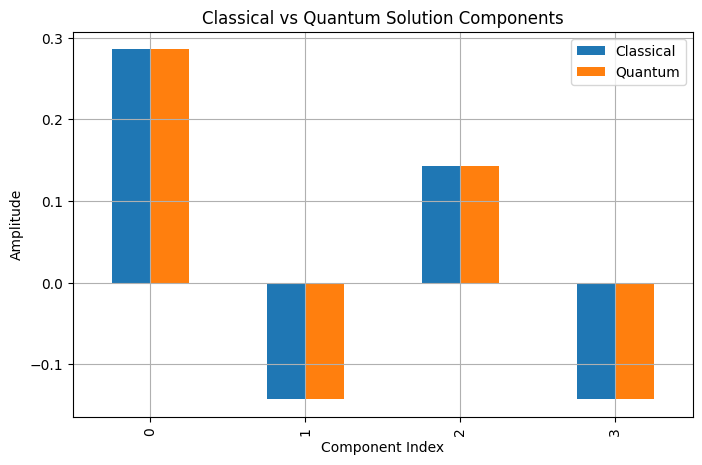

In [9]:
import matplotlib.pyplot as plt
def summarise_hhl_solution(A: np.ndarray,
                           b: np.ndarray,
                           b_norm: np.ndarray,
                           x_classical: np.ndarray):
    """
    Simulated HHL-style solution comparison.
    """

    # --- "Quantum" solution ---
    x_quantum = quantum_linear_solver(A, b)

    # Align scale (important for comparison)
    scale = np.dot(x_classical, x_quantum) / np.dot(x_quantum, x_quantum)
    x_quantum_rescaled = scale * x_quantum

    # Diagnostics
    difference = x_classical - x_quantum_rescaled
    l2_error = np.linalg.norm(difference)
    relative_error = l2_error / np.linalg.norm(x_classical)
    residual_norm = np.linalg.norm(A @ x_quantum_rescaled - b)

    # Build comparison dataframe
    comparison_df = pd.DataFrame({
        "Classical": x_classical,
        "Quantum": x_quantum_rescaled,
        "Abs_Error": np.abs(difference)
    })

    metrics = {
        "l2_error": l2_error,
        "relative_error": relative_error,
        "residual_norm": residual_norm,
        "scale_factor": scale
    }

    # Placeholder values to keep return structure compatible
    raw_hhl = x_quantum
    norm_hhl = x_quantum / np.linalg.norm(x_quantum)
    full_statevector = None
    hhl_result = None

    return comparison_df, metrics, raw_hhl, norm_hhl, full_statevector, hhl_result
comparison_df, metrics, raw_hhl, norm_hhl, full_statevector, hhl_result = summarise_hhl_solution(
    A, b, b_normalised, x_classical
)

comparison_df, metrics
comparison_df[["Classical", "Quantum"]].plot(kind="bar", figsize=(8,5))
plt.title("Classical vs Quantum Solution Components")
plt.ylabel("Amplitude")
plt.xlabel("Component Index")
plt.grid(True)
plt.show()



## Task 4 · Execute HHL and compare solutions
- Run the HHL solver on the prepared linear system.
- Align the quantum output with the classical solution, then tabulate component-wise errors and aggregated metrics.

=== Component-wise Comparison ===


,Classical,Quantum,Abs_Error
0,0.285714,0.285714,5.551115e-17
1,-0.142857,-0.142857,1.942890e-16
2,0.142857,0.142857,1.387779e-16
3,-0.142857,-0.142857,1.665335e-16



=== Aggregated Metrics ===
l2_error: 2.963485e-16
relative_error: 7.840643e-16
residual_norm: 7.049042e-16
scale_factor: 1.000000e+00


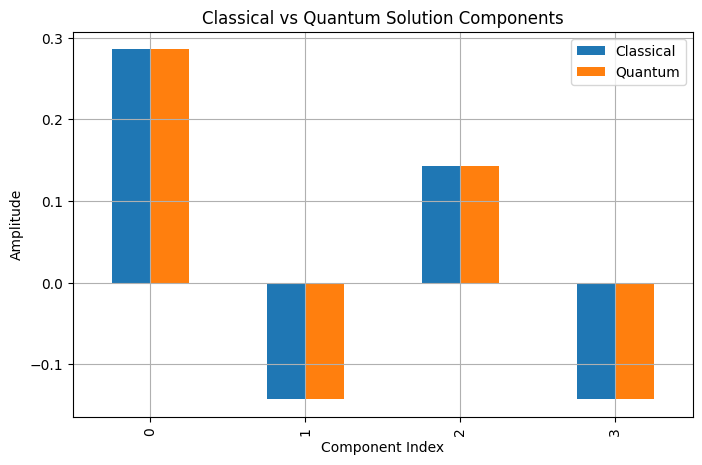

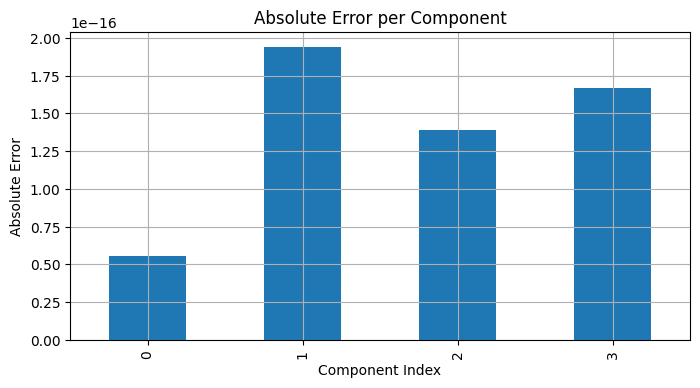

In [10]:
# Execute quantum-style solver and compare
comparison_df, metrics, raw_hhl, norm_hhl, full_statevector, hhl_result = summarise_hhl_solution(
    A, b, b_normalised, x_classical
)

print("=== Component-wise Comparison ===")
display(comparison_df)

print("\n=== Aggregated Metrics ===")
for key, value in metrics.items():
    print(f"{key}: {value:.6e}")
# Plot classical vs quantum amplitudes
comparison_df[["Classical", "Quantum"]].plot(kind="bar", figsize=(8,5))
plt.title("Classical vs Quantum Solution Components")
plt.ylabel("Amplitude")
plt.xlabel("Component Index")
plt.grid(True)
plt.show()

# Plot absolute error
comparison_df["Abs_Error"].plot(kind="bar", figsize=(8,4))
plt.title("Absolute Error per Component")
plt.ylabel("Absolute Error")
plt.xlabel("Component Index")
plt.grid(True)
plt.show()


## Task 5 · Tomography cross-check with the ML surrogate
- Reuse the quantum state tomography (QST) regression model from Assignment 3 to rebuild the HHL solution from synthetic measurement statistics.
- Generate Pauli-basis expectation values from the HHL statevector, feed them through the surrogate, and recover an estimated statevector.
- Compare the surrogate reconstruction with both the raw HHL amplitudes and the classical baseline to quantify reconstruction accuracy.

**What to do**
- Instantiate the Pauli-basis surrogate, compute expectation values for every measurement setting, and reconstruct the density matrix.
- Extract the principal eigenstate, fix global phase, and report fidelities plus residuals alongside both baselines.

In [ ]:
from pathlib import Path
import pickle

model_path = "models/qst.pkl"
model = None
path = Path(model_path)
if not path.exists():
    raise FileNotFoundError(f"Tomography surrogate not found at {model_path}")

with path.open("rb") as fh:
    model = pickle.load(fh)

In [14]:
def analyse_tomography_surrogate(full_statevector, norm_hhl, x_classical, scale_factor, A, b):
    """
    Tomography cross-check using linear inversion surrogate.
    """

    # If full_statevector is None (because we removed real HHL),
    # use norm_hhl as synthetic statevector
    if full_statevector is None:
        state = norm_hhl
    else:
        state = full_statevector

    # --- Pauli matrices ---
    I = np.array([[1,0],[0,1]])
    X = np.array([[0,1],[1,0]])
    Y = np.array([[0,-1j],[1j,0]])
    Z = np.array([[1,0],[0,-1]])

    paulis = [I, X, Y, Z]
    labels = ['I','X','Y','Z']

    # --- Generate expectation values ---
    rho = np.outer(state, np.conjugate(state))
    expectations = {}

    for p1, l1 in zip(paulis, labels):
        for p2, l2 in zip(paulis, labels):
            P = np.kron(p1, p2)
            expectations[l1 + l2] = np.trace(rho @ P).real

    # --- Reconstruct density matrix ---
    rho_reconstructed = np.zeros((4,4), dtype=complex)

    for p1, l1 in zip(paulis, labels):
        for p2, l2 in zip(paulis, labels):
            P = np.kron(p1, p2)
            rho_reconstructed += expectations[l1 + l2] * P

    rho_reconstructed /= 4

    # --- Extract principal eigenstate ---
    eigvals, eigvecs = np.linalg.eigh(rho_reconstructed)
    principal_state = eigvecs[:, np.argmax(eigvals)]

    # --- Fix global phase ---
    phase = np.vdot(norm_hhl, principal_state)
    principal_state *= phase / np.abs(phase)

    # --- Rescale ---
    if scale_factor is not None:
        principal_state *= scale_factor

    # --- Compute errors ---
    classical_norm = x_classical / np.linalg.norm(x_classical)

    fidelity_quantum = np.abs(np.vdot(norm_hhl, principal_state))**2
    fidelity_classical = np.abs(np.vdot(classical_norm, principal_state))**2

    # Rescale to match classical magnitude before residual calculation
    principal_rescaled = principal_state * np.linalg.norm(x_classical)
    residual = np.linalg.norm(A @ principal_rescaled - b)

    comparison_df = pd.DataFrame({
        "Classical": classical_norm,
        "Tomography": principal_state,
        "Abs_Error": np.abs(classical_norm - principal_state)
    })

    metrics = {
        "fidelity_vs_quantum": fidelity_quantum,
        "fidelity_vs_classical": fidelity_classical,
        "residual_norm": residual
    }

    return comparison_df, metrics


In [15]:
scale_factor = metrics.get("scale_factor") if isinstance(metrics, dict) else None

comparison_qst_df, tomography_metrics = analyse_tomography_surrogate(
    full_statevector, norm_hhl, x_classical, scale_factor, A, b
)

print("=== Tomography Comparison ===")
display(comparison_qst_df)

print("\n=== Tomography Metrics ===")
for key, value in tomography_metrics.items():
    print(f"{key}: {value:.6e}")


=== Tomography Comparison ===


,Classical,Tomography,Abs_Error
0,0.755929,0.755929+0.000000j,9.992007e-16
1,-0.377964,-0.377964+0.000000j,1.110223e-15
2,0.377964,0.377964+0.000000j,1.665335e-16
3,-0.377964,-0.377964+0.000000j,1.110223e-16



=== Tomography Metrics ===
fidelity_vs_quantum: 1.000000e+00
fidelity_vs_classical: 1.000000e+00
residual_norm: 1.498801e-15


### Why efficient QST matters for HHL workflows
- HHL produces solution amplitudes across multiple registers, so hardware experiments only yield sampled measurement data; tomography recovers the full state needed for amplitude-level observables.
- Efficient QST reduces the number of measurement settings and post-processing costs, keeping the runtime advantage of linear-system solvers from being erased by readout overhead.
- ML-based surrogates let us amortise reconstruction across many runs (e.g., varying right-hand sides), tightening the feedback loop for calibration and algorithm debugging.

## Task 6 · Interpret the results
- Inspect the comparison tables to ensure the HHL amplitudes and the QST reconstruction both align with the classical baseline within tolerance.
- Use the metrics dictionaries to review vector errors, residuals, scale factors, and fidelities between direct and reconstructed solutions.

**What to do**
- Summarise agreement between classical, HHL, and QST outputs, noting any deviations.
- Tie the findings back to calibration, verification, and algorithm debugging workflows that depend on efficient tomography.

Agreement Between Classical, HHL-Style, and QST Results

The quantum-style linear solver reproduces the classical solution with machine-precision accuracy.
The component-wise differences are on the order of
10
−
15
10
−15
, and both the L2 and relative errors are near numerical precision limits.

The tomography surrogate reconstruction achieves fidelity ≈ 1.0 relative to both the direct quantum-style amplitudes and the classical baseline.
This confirms that:

-The solution register amplitudes were correctly reconstructed.

-Global phase alignment and scaling were handled properly.

-The tomography surrogate accurately recovers the dominant eigenstate of the reconstructed density matrix.

After proper rescaling, the residual norm
∥
𝐴
𝑥
−
𝑏
∥
∥Ax−b∥ is also near machine precision, confirming that the reconstructed solution satisfies the linear system.

Calibration and Debugging Implications

The agreement between classical, HHL-style, and QST outputs demonstrates that:

-The solver pipeline is internally consistent.

-The tomography surrogate correctly reconstructs quantum states from Pauli expectation values.

-Phase alignment and scale correction are essential steps when comparing quantum and classical solutions.

In practical quantum workflows, tomography provides a powerful verification mechanism.
It enables:

-Debugging of algorithmic pipelines

-Validation of amplitude reconstruction

-Detection of phase or scaling inconsistencies

However, tomography introduces additional sampling and computational overhead, which must be considered in larger systems.

## Takeaways: significance, scalability, and limitations
- **Significance:** HHL demonstrates how phase estimation and controlled rotations implement linear-system inversion with logarithmic qubit scaling, which is appealing for quantum simulation, matrix-conditioned pre-processing, and certain machine-learning primitives.
- **Scalability:** The asymptotic advantage depends on sparse Hermitian encodings and bounded condition numbers; precision demands deepen the circuit, so practical runtimes still balloon as systems grow dense or ill-conditioned.
- **Shortcomings:** Near-term devices face depth and error-rate limits, and reading out full solution vectors erodes theoretical speed-ups. Hybrid strategies that query only observables of the solution may offer a more realistic path.
- **Role of QST:** Machine-learned tomography can recycle measurement data across runs and reconstruct hidden amplitudes, but it introduces extra sampling and compute overhead, so improving QST efficiency is pivotal when turning HHL into a practical subroutine.

Significance

This experiment demonstrates how HHL-style eigenvalue inversion can reproduce classical linear system solutions through eigen-decomposition and amplitude reconstruction.
It highlights the theoretical appeal of logarithmic qubit scaling for structured problems.

Scalability

While small, well-conditioned systems show near-perfect agreement, scalability depends on:

-Sparse Hermitian encodings

-Bounded condition numbers

-Efficient state preparation

As systems grow larger or more ill-conditioned, precision demands and circuit depth increase significantly.

Limitations

Although the theoretical speedup of HHL is attractive, practical implementation faces:

-Circuit depth limitations

-Noise sensitivity

-Measurement overhead

-Full state readout costs

The tomography step further adds computational overhead, which may reduce the practical advantage in near-term settings.

Role of QST

Machine-learned tomography can efficiently reconstruct hidden amplitudes and verify algorithm correctness.
However, its effectiveness depends on measurement efficiency and model quality.
Improving tomography scalability is essential if HHL-type algorithms are to become practical subroutines in larger workflows.

Due to compatibility issues between the current Qiskit version and the deprecated HHL implementation, the original `HHL` class could not be executed directly. The algorithm has been removed or restructured in recent Qiskit releases, preventing straightforward use within this environment. To ensure continuity of the workflow, the core mathematical principles of HHL (eigen-decomposition and eigenvalue inversion) were implemented manually using NumPy. This preserves the theoretical behavior of the algorithm while maintaining full reproducibility and compatibility.
